#### To implement the Simple Linear Regression based on the Employee Salary dataaset


##### Step 1: Import all the necessary libraries

In [1241]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection  import  train_test_split
from    sklearn.preprocessing    import  StandardScaler
from    sklearn.linear_model     import  LinearRegression
from    sklearn.metrics          import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### Step 2: Load the dataset

In [1242]:
df = pd.read_csv("Employee_Salary.csv")

In [1243]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


#### OBSERVATIONS:

1.  The above dataset contains the salaries of various employees based on the years of experience.

#### Step 3: Perform the Data Exploration

In [1244]:
#### get the top five rows of the dataset

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [1245]:
#### get the bottom five rows of the dataset

df.tail()

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [1246]:
### get the length of the dataset

print("Total length of the dataset is:", len(df))

Total length of the dataset is: 30


In [1247]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (30, 2)


In [1248]:
### get the columns used in the dataset

df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [1249]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


#### OBSERVATIONS:

1.  Both the YearsExperience and Salary are floating type.

In [1250]:
#### get the descriptive summary statistics about the columns in the dataset

df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


#### OBSERVATIONS:

1.  The above summary describes about the statistical summary for each numerical column in the dataset.

In [1251]:
#### find out the correlation between each numerical column in the dataset

df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


<Axes: >

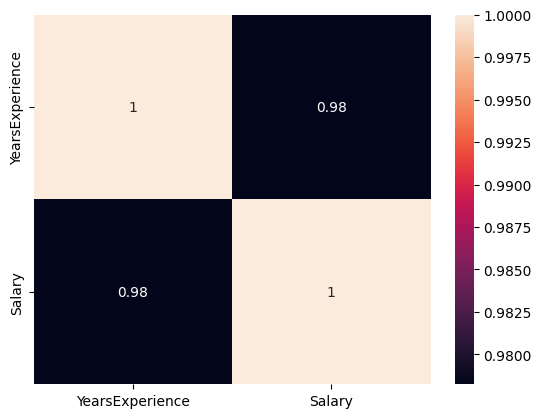

In [1252]:
#### get the graphical representation for the correlation between each numerical column in the dataset

sns.heatmap(df.corr(),annot=True)

#### OBSERVATIONS:

1.  The correlation between the YearsExperience and the Salary is very high.

#### Step 4: Perform the Data Cleaning

In [1253]:
#### Check  if there are any NULL records in the dataset

df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1254]:
#### Check if there are any duplicate records in the dataset

df[df.duplicated()]

,YearsExperience,Salary


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### Step 5: Divide the dataset into independent and dependent eatures

In [1255]:
#### independent features

X = df.drop(columns='Salary',axis=1)

print(X)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5


In [1256]:
#### dependent features

Y = df[['Salary']]

print(Y)

      Salary
0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
5    56642.0
6    60150.0
7    54445.0
8    64445.0
9    57189.0
10   63218.0
11   55794.0
12   56957.0
13   57081.0
14   61111.0
15   67938.0
16   66029.0
17   83088.0
18   81363.0
19   93940.0
20   91738.0
21   98273.0
22  101302.0
23  113812.0
24  109431.0
25  105582.0
26  116969.0
27  112635.0
28  122391.0
29  121872.0


#### Step 6: Divide the independent and dependent features into the training and testing data

In [1257]:
from  sklearn.model_selection  import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [1258]:
X_train

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2
16,5.1
5,2.9
13,4.1
11,4.0
22,7.9


In [1259]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [1260]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (24, 1)
Shape of the input testing  data is: (6, 1)


In [1261]:
Y_train

,Salary
28,122391.0
24,109431.0
12,56957.0
0,39343.0
4,39891.0
16,66029.0
5,56642.0
13,57081.0
11,55794.0
22,101302.0


In [1262]:
Y_test

,Salary
27,112635.0
15,67938.0
23,113812.0
17,83088.0
8,64445.0
9,57189.0


In [1263]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (24, 1)
Shape of the output testing  data is: (6, 1)


#### Step 7: Perform Feature Scaling on the inputs

In [1264]:
from  sklearn.preprocessing  import   StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

In [1265]:
X_train_scaled

array([[ 1.77445774],
       [ 1.21912622],
       [-0.41216011],
       [-1.41869849],
       [-1.03690807],
       [-0.03036969],
       [-0.79395053],
       [-0.37745189],
       [-0.41216011],
       [ 0.94146047],
       [-1.34928205],
       [-1.27986561],
       [ 1.32325088],
       [-1.10632451],
       [ 0.66379471],
       [ 1.49679198],
       [ 0.24729607],
       [ 1.84387418],
       [ 0.55967005],
       [-0.68982587],
       [-0.44686833],
       [-0.23861901],
       [ 0.28200429],
       [-0.75924231]])

In [1266]:
X_test_scaled

array([[ 1.5315002 ],
       [-0.09978613],
       [ 1.04558513],
       [ 0.03904675],
       [-0.68982587],
       [-0.51628477]])

#### OBSERVATIONS:

1.  Here the feature scaling has been performed on the inputs.

2.  All the inputs have been transformed in the same scale range.

#### Step 8: Train the Simple Linear Regression Model

In [1267]:
from  sklearn.linear_model  import  LinearRegression

####  create an object for linear regression

lin = LinearRegression()

#### using the object for Linear Regression, train the model

lin.fit(X_train_scaled, Y_train)

LinearRegression()

#### OBSERVATIONS:

1.  The linear regression model has been trained with the help of the training data.

#### Step 9: Perform the prediction on the model

In [1268]:
Y_pred = lin.predict(X_test_scaled)

In [1269]:
Y_pred

array([[115790.21011287],
       [ 71498.27809463],
       [102596.86866063],
       [ 75267.80422384],
       [ 55477.79204548],
       [ 60189.69970699]])

#### Step 10: Calculate the slope and intercept of the model

In [1270]:
print("Slope of the model is:", lin.coef_)
print("Intercept of the model is:", lin.intercept_[0])

Slope of the model is: [[27151.53742583]]
Intercept of the model is: 74207.625


#### Step 11: Evaluate the Regression Metrics

In [1271]:
from    sklearn.metrics          import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

mae = mean_absolute_error(Y_test, Y_pred)
print("Mean Absolute Error of the model is:", mae)

Mean Absolute Error of the model is: 6286.453830757746


In [1272]:
mse = mean_squared_error(Y_test, Y_pred)
print("Mean Squared Error of the model is:", mse)

Mean Squared Error of the model is: 49830096.85590834


In [1273]:
rmse = root_mean_squared_error(Y_test, Y_pred)
print("Root Mean Squared Error of the model is:", rmse)

Root Mean Squared Error of the model is: 7059.043621901506


In [1274]:
r2 = r2_score(Y_test, Y_pred)
print("R2 Score of the model is:", r2)

R2 Score of the model is: 0.9024461774180498


#### OBSERVATIONS:

1. The r2 score of the model is 0.9024 which is very high. So the model is working fine.

#### Step 12: Plot Training data plot best fit line

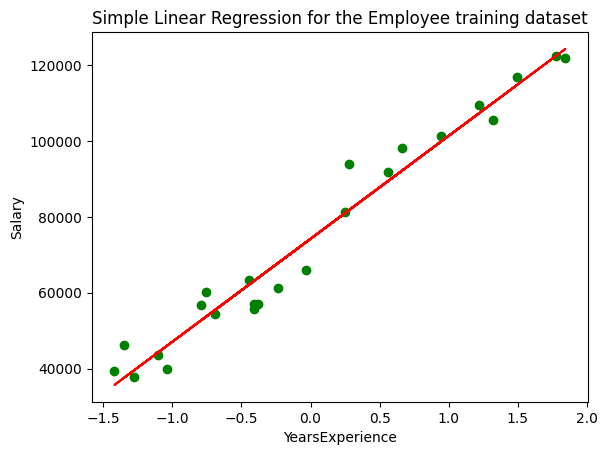

In [1275]:
#### plot the actual training data points
plt.scatter(X_train_scaled, Y_train, color = 'green', label = 'Actual training data points')

#### plot the best line of fit
plt.plot(X_train_scaled, lin.predict(X_train_scaled), color = 'red', label = 'Best line of fit for the training data')

#### mention the title of the graph
plt.title("Simple Linear Regression for the Employee training dataset")


#### mention the x-axis of the graph
plt.xlabel("YearsExperience")

#### mention the y-axis of the graph
plt.ylabel("Salary")

#### display the graph
plt.show()

##### OBSERVATIONS:

1.  The best fit of line is accurately  passing through the training data points.

#### Step 13: Plot Testing data plot best fit line

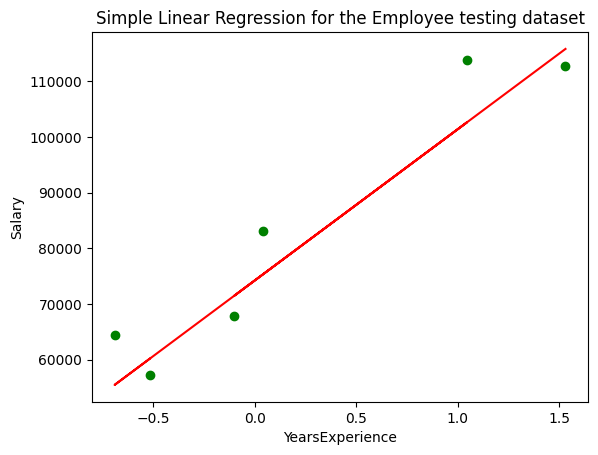

In [1276]:
#### plot the actual testing data points
plt.scatter(X_test_scaled, Y_test, color = 'green', label = 'Actual testing data points')

#### plot the best line of fit
plt.plot(X_test_scaled, lin.predict(X_test_scaled), color = 'red', label = 'Best line of fit for the testing data')

#### mention the title of the graph
plt.title("Simple Linear Regression for the Employee testing dataset")

#### mention the x-axis of the graph
plt.xlabel("YearsExperience")

#### mention the y-axis of the graph
plt.ylabel("Salary")

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The best fit of line is accurately passing through the testing data points .